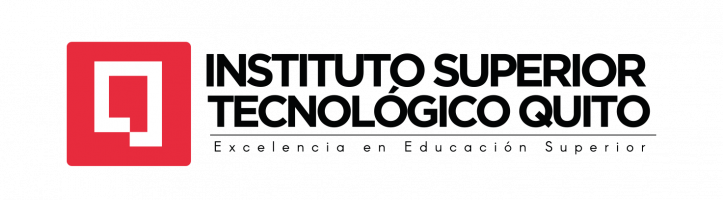

## EXAMEN PARCIAL 1 

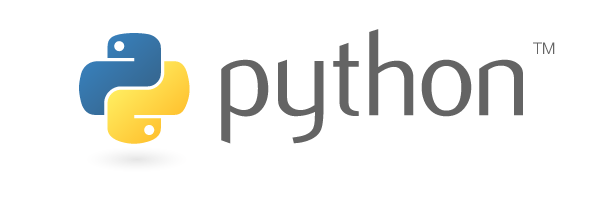

*Byron Melo*

*[Enlace a Github](https://github.com/ByronMN911/Machine-Learning-II/tree/main/pr%C3%A1cticas/Parcial%20I/Prueba)*

## OBJETIVO

Desarrollar un proceso completo de Machine Learning para construir un modelo de regresión lineal múltiple capaz de estimar los gastos médicos (charges) a partir de las características disponibles en el conjunto de datos insurance, aplicando análisis exploratorio, tratamiento de datos, detección de valores atípicos, transformación de variables, selección de atributos, validación, entrenamiento, evaluación y predicción de nuevas observaciones.

## PIPELINE DEL PROYECTO

| Fase | Entrada | Proceso | Salida |
|---|---|---|---|
| 1. Carga y comprensión | Identificador del dataset en Kaggle | Descarga automatizada con la API de Kaggle, lectura del CSV e inspección inicial | df |
| 2. EDA y calidad | df | Nulos, duplicados, consistencia, rangos, distribuciones, relaciones y correlaciones | df depurado |
| 3. Outliers | df | Método IQR, análisis por grupo y tratamiento documentado | df_clean |
| 4. Preparación de variables | df_clean | Codificación, variables derivadas y partición entrenamiento/prueba | X_train, X_test, y_train, y_test |
| 5. Normalización o estandarización | X_train, X_test | Comparación de escaladores y ajuste de StandardScaler solo con entrenamiento | X_train_sc, X_test_sc |
| 6. Selección de atributos | X_train_sc, y_train | Correlación, prueba F, información mutua, VIF y RFECV | SELECCIONADAS |
| 7. Validación de datos | X_train, X_test | Integridad, representatividad de la partición y validación cruzada | Configuración final del modelo |
| 8. Entrenamiento | X_train, y_train | Pipeline con escalado y LinearRegression | modelo_final |
| 9. Evaluación | modelo_final, X_test, y_test | R², R² ajustado, MAE, RMSE y diagnóstico de residuos | Métricas y gráficos |
| 10. Predicción | Nuevas observaciones | Preparación de variables, modelo persistido y predicción | charges estimados |

In [1]:
# =====================================================================
# CONFIGURACIÓN GLOBAL
# =====================================================================
# Todas las importaciones y constantes del proyecto se centralizan en esta celda para facilitar la reproducibilidad
import os
from getpass import getpass
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from scipy import stats
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.feature_selection import RFECV, f_regression, mutual_info_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

# Semilla global: garantiza que la partición, la validación cruzada y la
# información mutua produzcan los mismos resultados en cada ejecución.
SEMILLA = 42
np.random.seed(SEMILLA)

# Parámetros del dataset y rutas de trabajo
DATASET_NAME = 'mirichoi0218/insurance'
BASE_DIR = Path('datasetprueba')
CSV_FILE = BASE_DIR / 'insurance.csv'
MODELOS_DIR = Path('modelos')

# Definición de columnas por tipo
TARGET = 'charges'
CATEGORICAS = ['sex', 'smoker', 'region']
NUMERICAS = ['age', 'bmi', 'children', 'charges']

# Estilo visual y formato de salida de los números
sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:,.4f}'.format

## PASO 1: Carga y comprensión de los datos — 10 %

### 1.1 Descarga automatizada desde Kaggle

La descarga se realiza desde Python mediante la API oficial de Kaggle y por seguridad el token de la API no se escribe en el código del notebook porque un token expuesto en un archivo o en un repositorio permite a terceros usar la cuenta. La celda busca las credenciales en el siguiente orden: variable de entorno KAGGLE_API_TOKEN, archivo ~/.kaggle/access_token o ~/.kaggle/kaggle.json, y, como último recurso, solicita el token de forma interactiva mediante getpass sin almacenarlo en el archivo.

Adicionalmente, la descarga solo se ejecuta si el archivo CSV no existe localmente, lo que evita descargas redundantes y automatiza la descarga del dataset.

In [2]:
# =====================================================================
# 1.1 DESCARGA AUTOMATIZADA DEL DATASET
# =====================================================================
def existen_credenciales_kaggle() -> bool:
    """Indica si existe alguna credencial de Kaggle disponible en el equipo."""
    carpeta_kaggle = Path.home() / '.kaggle'
    return any([
        bool(os.environ.get('KAGGLE_API_TOKEN')),
        (carpeta_kaggle / 'access_token').exists(),
        (carpeta_kaggle / 'kaggle.json').exists(),
        bool(os.environ.get('KAGGLE_USERNAME') and os.environ.get('KAGGLE_KEY')),
    ])


def descargar_dataset(dataset: str, destino: Path, archivo: str) -> Path:
    """Descarga y descomprime el dataset de Kaggle si el archivo no existe localmente.

    Devuelve la ruta del archivo CSV y detiene la ejecución si el archivo
    esperado no está disponible al finalizar el proceso.
    """
    ruta_csv = destino / archivo

    if ruta_csv.exists():
        print('[INFO] Dataset previamente descargado en el directorio local.')
        return ruta_csv

    if not existen_credenciales_kaggle():
        # El token se solicita en pantalla para que nunca quede escrito en el notebook.
        os.environ['KAGGLE_API_TOKEN'] = getpass('Token de la API de Kaggle: ')

    # La importación se realiza en este punto porque el paquete kaggle
    # intenta autenticarse en el momento de ser importado.
    import kaggle

    print('[INFO] Iniciando descarga del dataset desde Kaggle...')
    destino.mkdir(parents=True, exist_ok=True)
    kaggle.api.dataset_download_files(dataset, path=str(destino), unzip=True)

    if not ruta_csv.exists():
        raise FileNotFoundError(f'No se encontró {ruta_csv} después de la descarga.')
    return ruta_csv


CSV_FILE = descargar_dataset(DATASET_NAME, BASE_DIR, 'insurance.csv')
print('[INFO] Rutas validadas correctamente. Listo para el análisis.')

# Lectura del archivo con la ruta validada
df = pd.read_csv(CSV_FILE)
df.head()

[INFO] Dataset previamente descargado en el directorio local.
[INFO] Rutas validadas correctamente. Listo para el análisis.


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9000,0,yes,southwest,"16,884.9240"
1,18,male,33.7700,1,no,southeast,"1,725.5523"
2,28,male,33.0000,3,no,southeast,"4,449.4620"
3,33,male,22.7050,0,no,northwest,"21,984.4706"
4,32,male,28.8800,0,no,northwest,"3,866.8552"


### 1.2 Diccionario de datos

| Variable | Tipo | Descripción |
|---|---|---|
| age | Numérica entera | Edad del beneficiario principal |
| sex | Categórica | Sexo del asegurado (female, male) |
| bmi | Numérica continua | Índice de masa corporal (kg/m²) |
| children | Numérica entera | Número de dependientes cubiertos por el seguro |
| smoker | Categórica | Condición de fumador (yes, no) |
| region | Categórica | Región residencial en EE. UU. (northeast, northwest, southeast, southwest) |
| charges | Numérica continua | Gastos médicos individuales facturados por el seguro. **Esta es la Variable objetivo** |

In [3]:
# =====================================================================
# 1.2 COMPRENSIÓN INICIAL DE LA ESTRUCTURA
# =====================================================================
# Dimensiones del dataset
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Columnas: {df.columns.tolist()}\n')

# Tipos de dato y cantidad de valores no nulos por columna
df.info()

Dimensiones: 1338 filas x 7 columnas
Columnas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
# =====================================================================
# 1.3 ESTADÍSTICA DESCRIPTIVA
# =====================================================================
# Resumen de las variables numéricas (mínimos, máximos, media y cuartiles)
print('[INFO] Estadística descriptiva de variables numéricas:')
display(df[NUMERICAS].describe().T)

# Resumen de las variables categóricas (categorías y frecuencias)
print('\n[INFO] Frecuencia de categorías:')
for columna in CATEGORICAS:
    print(f'\n{columna}:')
    print(df[columna].value_counts())

[INFO] Estadística descriptiva de variables numéricas:


,count,mean,std,min,25%,50%,75%,max
age,"1,338.0000",39.2070,14.0500,18.0000,27.0000,39.0000,51.0000,64.0000
bmi,"1,338.0000",30.6634,6.0982,15.9600,26.2963,30.4000,34.6938,53.1300
children,"1,338.0000",1.0949,1.2055,0.0000,0.0000,1.0000,2.0000,5.0000
charges,"1,338.0000","13,270.4223","12,110.0112","1,121.8739","4,740.2872","9,382.0330","16,639.9125","63,770.4280"



[INFO] Frecuencia de categorías:

sex:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


## PASO 2: EDA y calidad de los datos — 15 %

### 2.1 Calidad de los datos

La revisión de calidad cubre cuatro aspectos: valores nulos, registros duplicados, consistencia de las etiquetas categóricas y validez de los rangos de las variables numéricas. Los registros duplicados se eliminan porque repiten información y pueden sesgar la estimación del modelo y la evaluación (una misma observación podría quedar en entrenamiento y en prueba).

In [5]:
# =====================================================================
# 2.1 CALIDAD DE LOS DATOS
# =====================================================================
# 1. Valores nulos por columna (cantidad y porcentaje)
nulos = df.isnull().sum().to_frame('nulos')
nulos['porcentaje'] = nulos['nulos'] / len(df) * 100
print('[INFO] Valores nulos por columna:')
display(nulos)

# 2. Filas duplicadas
duplicados = df.duplicated().sum()
print(f'\n[INFO] Filas duplicadas encontradas: {duplicados}')
if duplicados > 0:
    display(df[df.duplicated(keep=False)])
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'[INFO] Se eliminaron los duplicados. Nuevo tamaño del dataset: {df.shape}')

# 3. Consistencia de las etiquetas categóricas (espacios y mayúsculas)
for columna in CATEGORICAS:
    df[columna] = df[columna].str.strip().str.lower()
    print(f'[INFO] Categorías en {columna}: {sorted(df[columna].unique())}')

# 4. Validación de rangos plausibles para cada variable numérica
rangos_validos = {
    'age': (18, 100),
    'bmi': (10, 70),
    'children': (0, 10),
    'charges': (0, np.inf),
}
print('\n[INFO] Registros fuera de los rangos plausibles:')
for columna, (minimo, maximo) in rangos_validos.items():
    fuera_de_rango = ((df[columna] < minimo) | (df[columna] > maximo)).sum()
    print(f'  {columna}: {fuera_de_rango}')

[INFO] Valores nulos por columna:


,nulos,porcentaje
age,0,0.0000
sex,0,0.0000
bmi,0,0.0000
children,0,0.0000
smoker,0,0.0000
region,0,0.0000
charges,0,0.0000



[INFO] Filas duplicadas encontradas: 1


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.5900,0,no,northwest,"1,639.5631"
581,19,male,30.5900,0,no,northwest,"1,639.5631"


[INFO] Se eliminaron los duplicados. Nuevo tamaño del dataset: (1337, 7)
[INFO] Categorías en sex: ['female', 'male']
[INFO] Categorías en smoker: ['no', 'yes']
[INFO] Categorías en region: ['northeast', 'northwest', 'southeast', 'southwest']

[INFO] Registros fuera de los rangos plausibles:
  age: 0
  bmi: 0
  children: 0
  charges: 0


### 2.2 Análisis univariado

El análisis univariado describe la forma de cada variable por separado. El coeficiente de asimetría (skewness) cuantifica el sesgo de las distribuciones numéricas: valores cercanos a 0 indican simetría y valores superiores a 1 indican una cola derecha pronunciada.

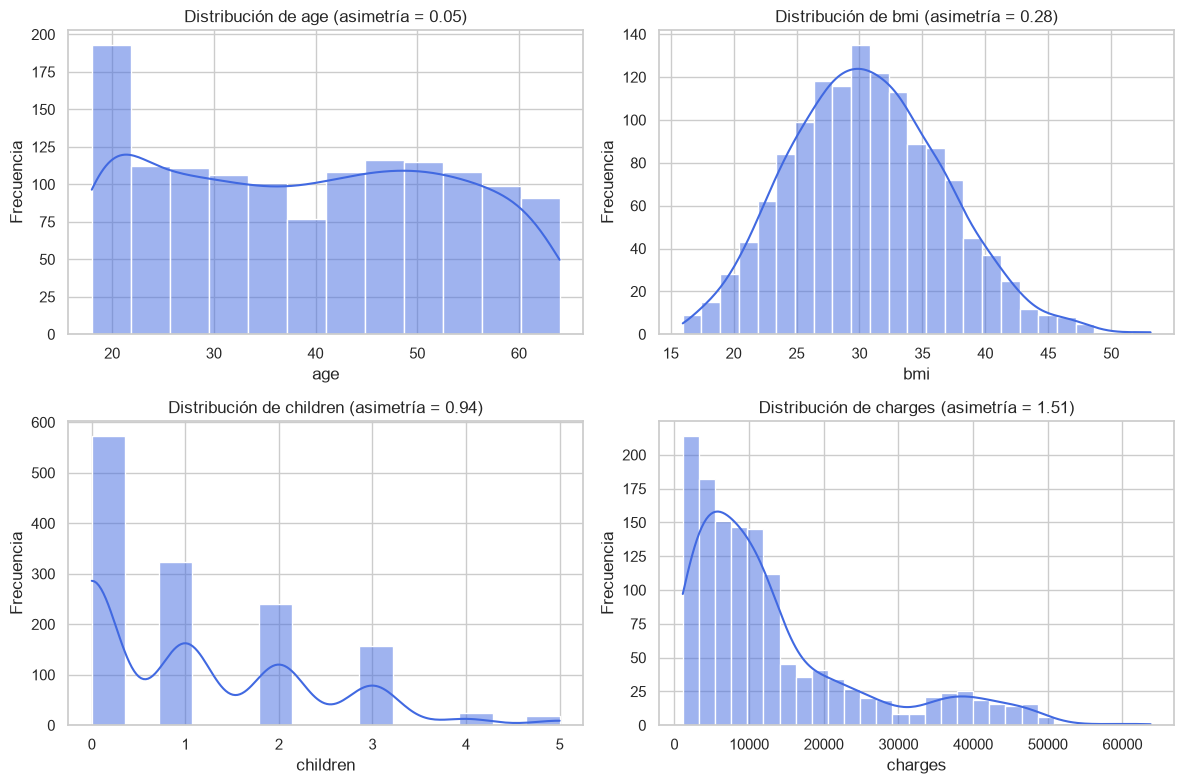

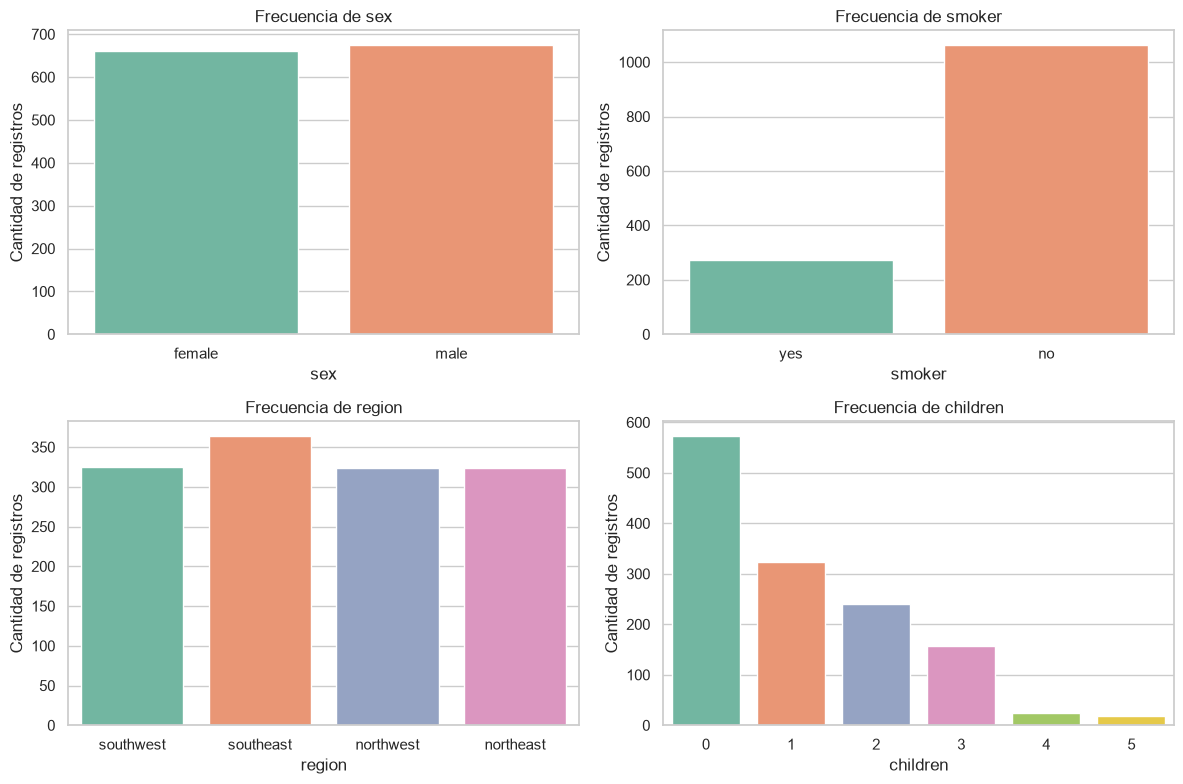

In [6]:
# =====================================================================
# 2.2 ANÁLISIS UNIVARIADO
# =====================================================================
# Distribución de las variables numéricas con su coeficiente de asimetría
fig, ejes = plt.subplots(2, 2, figsize=(12, 8))
for eje, columna in zip(ejes.ravel(), NUMERICAS):
    sns.histplot(df[columna], kde=True, color='royalblue', ax=eje)
    eje.set_title(f'Distribución de {columna} (asimetría = {stats.skew(df[columna]):.2f})')
    eje.set_xlabel(columna)
    eje.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Frecuencia de las variables categóricas y de la cantidad de hijos
fig, ejes = plt.subplots(2, 2, figsize=(12, 8))
for eje, columna in zip(ejes.ravel(), CATEGORICAS + ['children']):
    sns.countplot(data=df, x=columna, hue=columna, palette='Set2', legend=False, ax=eje)
    eje.set_title(f'Frecuencia de {columna}')
    eje.set_xlabel(columna)
    eje.set_ylabel('Cantidad de registros')
plt.tight_layout()
plt.show()

### 2.3 Análisis bivariado

El análisis bivariado estudia la relación de cada variable explicativa con la variable objetivo. Los diagramas de caja comparan la distribución de charges entre categorías, y los diagramas de dispersión coloreados por condición de fumador permiten observar posibles interacciones entre variables.

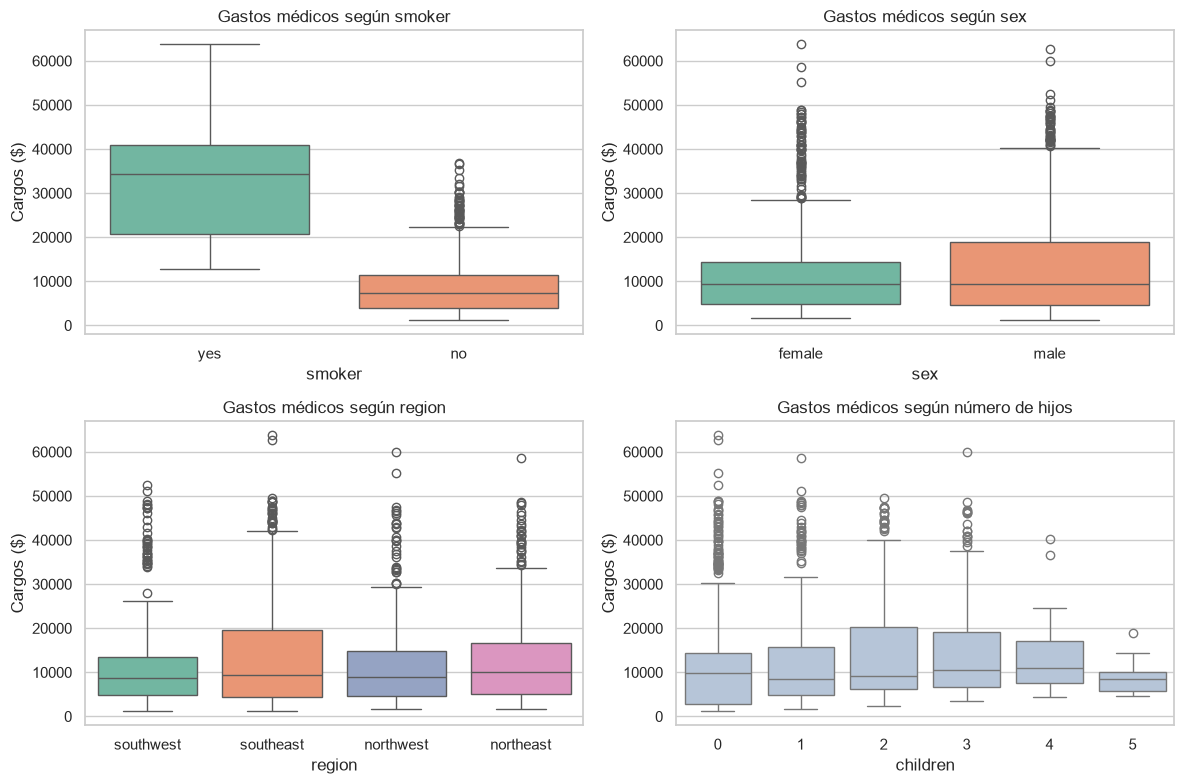

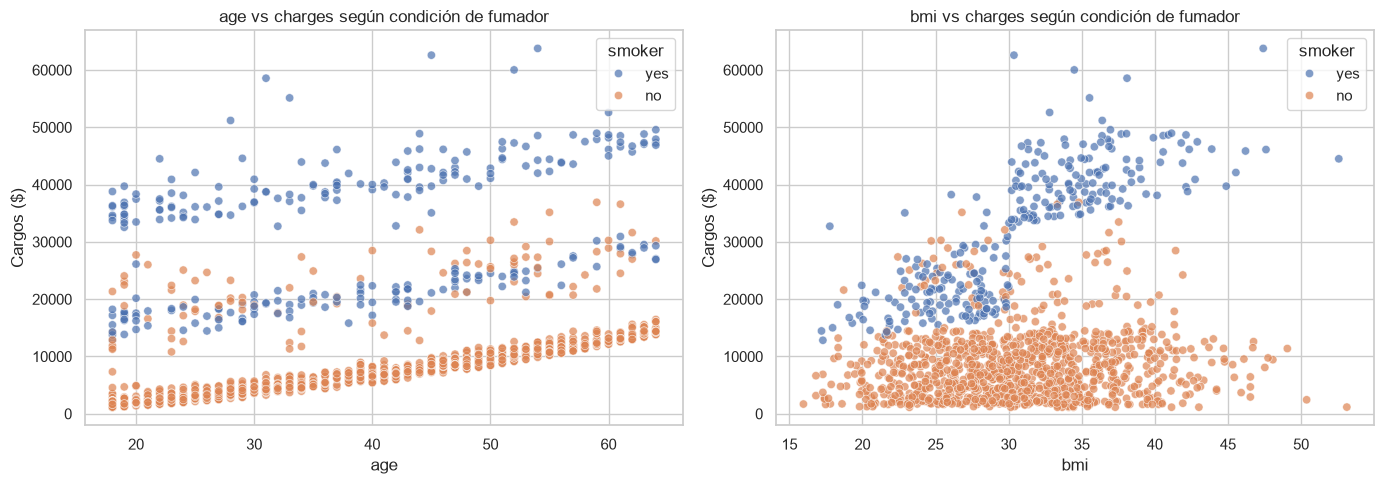

In [7]:
# =====================================================================
# 2.3 ANÁLISIS BIVARIADO
# =====================================================================
# Relación de las variables categóricas y de children con charges
fig, ejes = plt.subplots(2, 2, figsize=(12, 8))
for eje, columna in zip(ejes.ravel(), ['smoker', 'sex', 'region']):
    sns.boxplot(data=df, x=columna, y=TARGET, hue=columna, palette='Set2', legend=False, ax=eje)
    eje.set_title(f'Gastos médicos según {columna}')
    eje.set_ylabel('Cargos ($)')
sns.boxplot(data=df, x='children', y=TARGET, color='lightsteelblue', ax=ejes[1, 1])
ejes[1, 1].set_title('Gastos médicos según número de hijos')
ejes[1, 1].set_ylabel('Cargos ($)')
plt.tight_layout()
plt.show()

# Relación de las variables numéricas con charges, diferenciando por condición de fumador
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
for eje, columna in zip(ejes, ['age', 'bmi']):
    sns.scatterplot(data=df, x=columna, y=TARGET, hue='smoker', alpha=0.7, ax=eje)
    eje.set_title(f'{columna} vs charges según condición de fumador')
    eje.set_ylabel('Cargos ($)')
plt.tight_layout()
plt.show()

### 2.4 Correlaciones y análisis de la variable objetivo

La matriz de correlación incorpora las variables binarias codificadas (sexo y fumador) para medir también su asociación lineal con charges. Además, se evalúa si una transformación logarítmica reduce la asimetría de la variable objetivo, dado que la regresión lineal asume residuos aproximadamente simétricos.

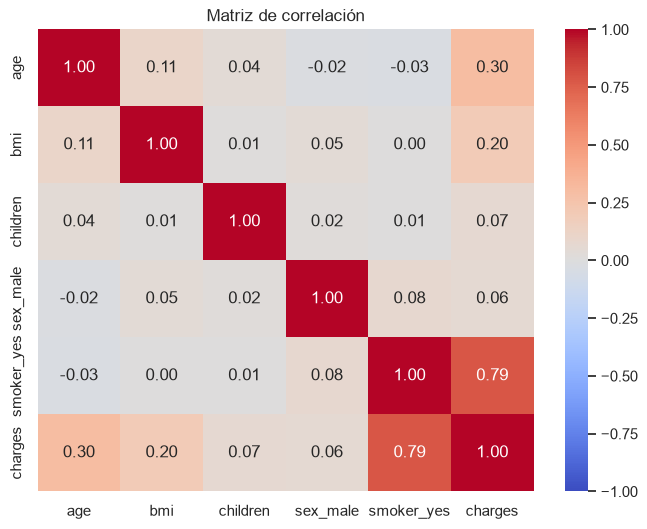

[INFO] Correlación de cada variable con charges:
smoker_yes   0.7872
age          0.2983
bmi          0.1984
children     0.0674
sex_male     0.0580
Name: charges, dtype: float64


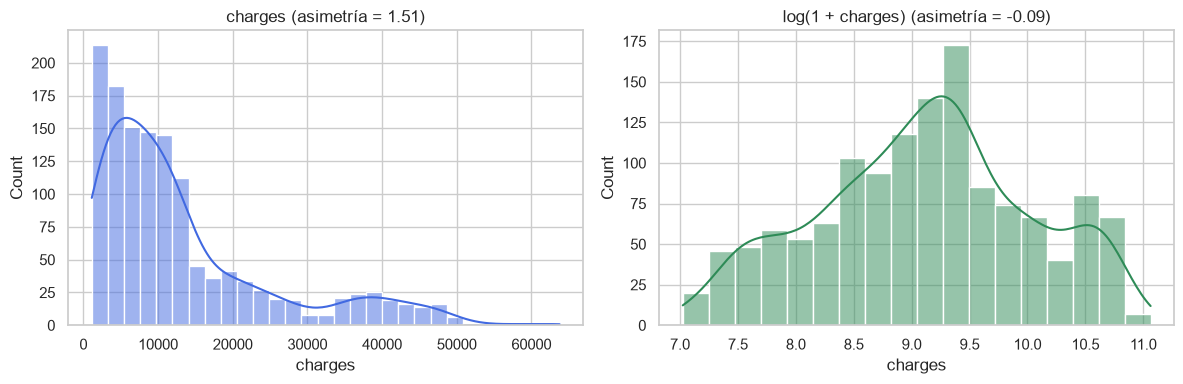

In [8]:
# =====================================================================
# 2.4 CORRELACIONES Y TRANSFORMACIÓN DE LA VARIABLE OBJETIVO
# =====================================================================
# Codificación temporal de las variables binarias solo para el cálculo de correlaciones
df_corr = df.assign(
    sex_male=(df['sex'] == 'male').astype(int),
    smoker_yes=(df['smoker'] == 'yes').astype(int),
)
columnas_corr = ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', TARGET]
matriz_corr = df_corr[columnas_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de correlación')
plt.show()

print('[INFO] Correlación de cada variable con charges:')
print(matriz_corr[TARGET].drop(TARGET).sort_values(ascending=False))

# Efecto de la transformación logarítmica sobre la asimetría de charges
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET], kde=True, color='royalblue', ax=ejes[0])
ejes[0].set_title(f'charges (asimetría = {stats.skew(df[TARGET]):.2f})')
sns.histplot(np.log1p(df[TARGET]), kde=True, color='seagreen', ax=ejes[1])
ejes[1].set_title(f'log(1 + charges) (asimetría = {stats.skew(np.log1p(df[TARGET])):.2f})')
plt.tight_layout()
plt.show()

### 2.5 Hallazgos del análisis exploratorio

- El dataset no presenta valores nulos y se detectó un registro duplicado, el cual fue eliminado.
- La variable objetivo charges presenta una distribución asimétrica hacia la derecha; la transformación logarítmica reduce de forma notable ese sesgo.
- La condición de fumador es la variable con mayor asociación con charges y separa los registros en dos grupos de costos claramente distintos.
- La edad muestra una relación creciente con charges, y el efecto del BMI parece intensificarse en los fumadores, lo que sugiere una interacción entre ambas variables.
- Los hallazgos anteriores motivan la creación de variables derivadas en el paso 4 y la evaluación de una transformación del objetivo en el paso 7.

## PASO 3: Detección de outliers — 10 %

### 3.1 Detección mediante el método IQR

El método del rango intercuartílico (IQR) clasifica como atípico todo valor fuera del intervalo [Q1 − (1.5)(IQR), Q3 + (1.5)(IQR)]. La detección se aplica a todas las variables numéricas y se complementa con un análisis por grupo de la variable charges, ya que los costos elevados podrían explicarse por la condición de fumador y no por errores de registro.

,limite_inferior,limite_superior,outliers,porcentaje
variable,,,,
age,-9.0000,87.0000,0,0.0000
bmi,13.6750,47.3150,9,0.6731
children,-3.0000,5.0000,0,0.0000
charges,"-13,120.7162","34,524.7776",139,10.3964


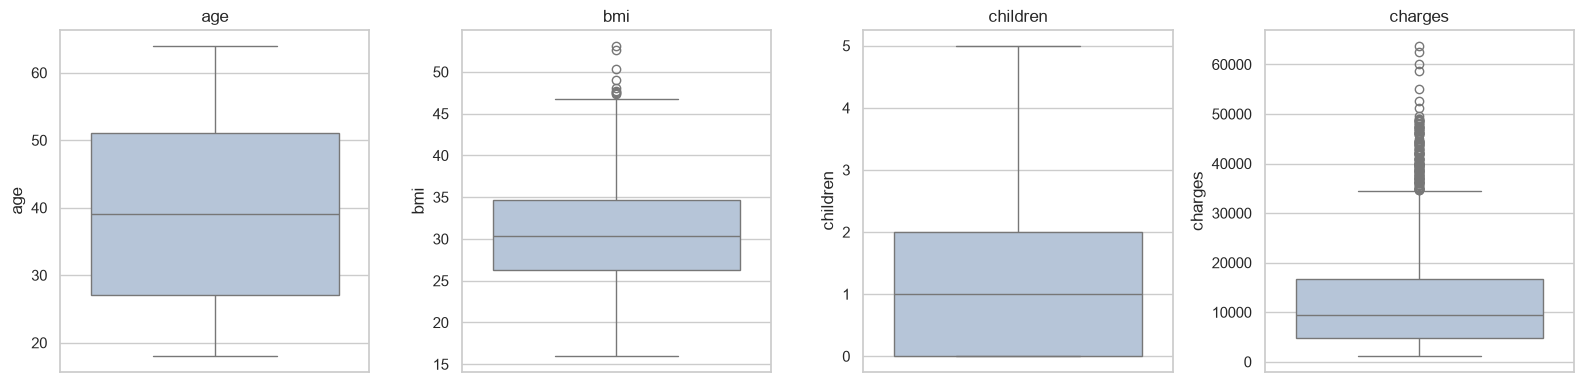

In [9]:
# =====================================================================
# 3.1 DETECCIÓN DE OUTLIERS (MÉTODO IQR)
# =====================================================================
def detectar_outliers_iqr(dataframe: pd.DataFrame, columna: str, factor: float = 1.5):
    """Detecta outliers con el método IQR.

    Devuelve los registros atípicos, el límite inferior y el límite superior.
    """
    q1 = dataframe[columna].quantile(0.25)
    q3 = dataframe[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - factor * iqr
    limite_superior = q3 + factor * iqr

    mascara = (dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)
    return dataframe[mascara], limite_inferior, limite_superior


# Resumen de outliers para todas las variables numéricas
resumen_outliers = []
resultados_iqr = {}
for columna in NUMERICAS:
    atipicos, inferior, superior = detectar_outliers_iqr(df, columna)
    resultados_iqr[columna] = (atipicos, inferior, superior)
    resumen_outliers.append({
        'variable': columna,
        'limite_inferior': inferior,
        'limite_superior': superior,
        'outliers': len(atipicos),
        'porcentaje': len(atipicos) / len(df) * 100,
    })
display(pd.DataFrame(resumen_outliers).set_index('variable'))

# Visualización de las variables numéricas mediante diagramas de caja
fig, ejes = plt.subplots(1, 4, figsize=(16, 4))
for eje, columna in zip(ejes, NUMERICAS):
    sns.boxplot(y=df[columna], color='lightsteelblue', ax=eje)
    eje.set_title(columna)
plt.tight_layout()
plt.show()

In [10]:
# =====================================================================
# 3.2 ANÁLISIS DE LOS OUTLIERS DE CHARGES POR GRUPO
# =====================================================================
outliers_charges = resultados_iqr[TARGET][0]

# Proporción de fumadores dentro de los outliers globales de charges
proporcion_fumadores = (outliers_charges['smoker'] == 'yes').mean() * 100
print(f'[INFO] Fumadores dentro de los outliers de charges: {proporcion_fumadores:.1f} %')

# Detección repetida dentro de cada grupo de fumador para comparar con el análisis global
print('\n[INFO] Outliers de charges calculados dentro de cada grupo:')
for grupo, datos_grupo in df.groupby('smoker'):
    atipicos_grupo, _, superior_grupo = detectar_outliers_iqr(datos_grupo, TARGET)
    print(f'  smoker = {grupo}: {len(atipicos_grupo)} outliers sobre {len(datos_grupo)} registros '
          f'(límite superior = {superior_grupo:,.2f})')

[INFO] Fumadores dentro de los outliers de charges: 97.8 %

[INFO] Outliers de charges calculados dentro de cada grupo:
  smoker = no: 46 outliers sobre 1063 registros (límite superior = 22,424.22)
  smoker = yes: 0 outliers sobre 274 registros (límite superior = 71,308.65)


### 3.3 Tratamiento de los outliers

La decisión se toma por variable, según la naturaleza de los valores atípicos:

- **charges**: se conservan. Los costos elevados corresponden en su mayoría a fumadores y reflejan un comportamiento real del fenómeno; eliminarlos haría que el modelo perdiera justamente los casos de mayor interés.
- **age y children**: no presentan valores atípicos relevantes, por lo que no requieren tratamiento.
- **bmi**: se eliminan los valores que superan el límite IQR. Son pocos registros, se encuentran en el extremo de la distribución y, en una regresión lineal, ejercen un efecto de palanca desproporcionado sobre los coeficientes.

El tratamiento se documenta con el detalle de los registros removidos y la comparación antes y después.

[INFO] Registros de bmi fuera del intervalo [13.67, 47.32]:


,age,sex,bmi,children,smoker,region,charges
116,58,male,49.0600,0,no,southeast,"11,381.3254"
286,46,female,48.0700,2,no,northeast,"9,432.9253"
401,47,male,47.5200,1,no,southeast,"8,083.9198"
543,54,female,47.4100,0,yes,southeast,"63,770.4280"
846,23,male,50.3800,1,no,southeast,"2,438.0552"
859,37,female,47.6000,2,yes,southwest,"46,113.5110"
1046,22,male,52.5800,1,yes,southeast,"44,501.3982"
1087,52,male,47.7400,1,no,southeast,"9,748.9106"
1316,18,male,53.1300,0,no,southeast,"1,163.4627"



[INFO] Dataset antes del tratamiento: (1337, 7)
[INFO] Dataset después del tratamiento: (1328, 7)
[INFO] Registros eliminados: 9 (0.67 %)


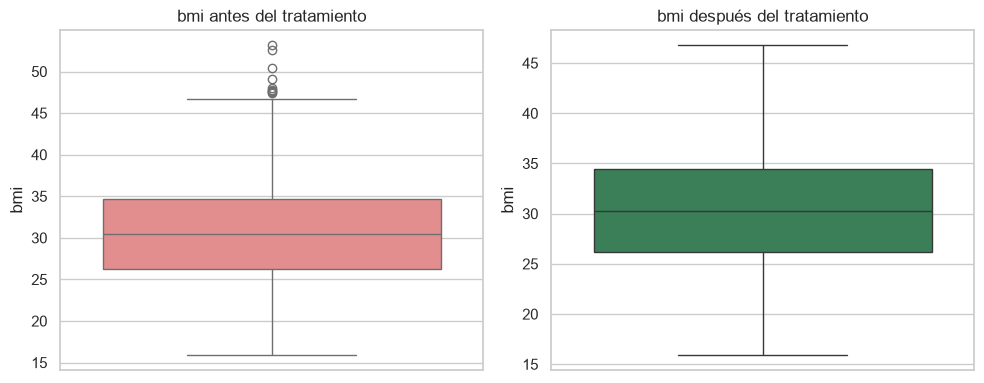

In [11]:
# =====================================================================
# 3.3 TRATAMIENTO DE LOS OUTLIERS
# =====================================================================
outliers_bmi, limite_inf_bmi, limite_sup_bmi = resultados_iqr['bmi']

print(f'[INFO] Registros de bmi fuera del intervalo [{limite_inf_bmi:.2f}, {limite_sup_bmi:.2f}]:')
display(outliers_bmi)

# Se eliminan únicamente los outliers de bmi; los de charges se conservan por su validez clínica
df_clean = df.drop(index=outliers_bmi.index).reset_index(drop=True)

eliminados = len(df) - len(df_clean)
print(f'\n[INFO] Dataset antes del tratamiento: {df.shape}')
print(f'[INFO] Dataset después del tratamiento: {df_clean.shape}')
print(f'[INFO] Registros eliminados: {eliminados} ({eliminados / len(df) * 100:.2f} %)')

# Comparación visual de bmi antes y después del tratamiento
fig, ejes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['bmi'], color='lightcoral', ax=ejes[0])
ejes[0].set_title('bmi antes del tratamiento')
sns.boxplot(y=df_clean['bmi'], color='seagreen', ax=ejes[1])
ejes[1].set_title('bmi después del tratamiento')
plt.tight_layout()
plt.show()

## PASO 4: Preparación de variables — 10 %

### 4.1 Codificación y variables derivadas

La regresión lineal requiere entradas numéricas, por lo que las variables categóricas se codifican de la siguiente forma:

- **sex y smoker** (binarias): codificación 0/1 en las columnas sex_male y smoker_yes.
- **region** (nominal de 4 categorías): codificación one-hot con northeast como categoría de referencia, lo que evita la multicolinealidad perfecta (trampa de las variables ficticias).

A partir de los hallazgos del EDA se agregan dos variables derivadas:

- **bmi_obeso**: indicador de obesidad (BMI mayor o igual a 30), según el criterio de la Organización Mundial de la Salud (2000).
- **fumador_obeso**: interacción entre smoker_yes y bmi_obeso. Permite que el modelo lineal capture el incremento adicional de costos que se observa cuando coinciden ambas condiciones.

Toda la lógica se encapsula en la función preparar_variables, de modo que exactamente la misma transformación se aplique en el entrenamiento y en la predicción de nuevos datos (paso 10), evitando inconsistencias entre ambas etapas.

In [12]:
# =====================================================================
# 4.1 FUNCIÓN DE PREPARACIÓN DE VARIABLES
# =====================================================================
# La primera región actúa como categoría de referencia en la codificación one-hot
REGIONES = ['northeast', 'northwest', 'southeast', 'southwest']
UMBRAL_OBESIDAD = 30
COLUMNAS_ENTRADA = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
COLUMNAS_CONTINUAS = ['age', 'bmi', 'children']


def preparar_variables(datos: pd.DataFrame) -> pd.DataFrame:
    """Transforma los datos originales en la matriz de características del modelo.

    Valida columnas y categorías, codifica las variables categóricas y genera las
    variables derivadas. Conserva el índice original para poder alinear con la
    variable objetivo.
    """
    faltantes = set(COLUMNAS_ENTRADA) - set(datos.columns)
    if faltantes:
        raise ValueError(f'Faltan columnas obligatorias: {sorted(faltantes)}')

    datos = datos[COLUMNAS_ENTRADA].copy()

    # Normalización del texto de las columnas categóricas
    for columna in CATEGORICAS:
        datos[columna] = datos[columna].astype(str).str.strip().str.lower()

    # Validación de categorías: un valor desconocido produciría codificaciones silenciosamente erróneas
    categorias_validas = {
        'sex': {'female', 'male'},
        'smoker': {'yes', 'no'},
        'region': set(REGIONES),
    }
    for columna, validas in categorias_validas.items():
        invalidas = set(datos[columna].unique()) - validas
        if invalidas:
            raise ValueError(f'Categorías no válidas en {columna}: {sorted(invalidas)}')

    caracteristicas = pd.DataFrame(index=datos.index)

    # Variables numéricas originales
    for columna in COLUMNAS_CONTINUAS:
        caracteristicas[columna] = pd.to_numeric(datos[columna], errors='raise')

    # Variables binarias
    caracteristicas['sex_male'] = (datos['sex'] == 'male').astype(int)
    caracteristicas['smoker_yes'] = (datos['smoker'] == 'yes').astype(int)

    # One-hot de region omitiendo la categoría de referencia
    for region in REGIONES[1:]:
        caracteristicas[f'region_{region}'] = (datos['region'] == region).astype(int)

    # Variables derivadas
    caracteristicas['bmi_obeso'] = (caracteristicas['bmi'] >= UMBRAL_OBESIDAD).astype(int)
    caracteristicas['fumador_obeso'] = caracteristicas['smoker_yes'] * caracteristicas['bmi_obeso']

    return caracteristicas

In [13]:
# =====================================================================
# 4.2 APLICACIÓN SOBRE EL DATASET LIMPIO
# =====================================================================
# Separación de la matriz de características (X) y la variable objetivo (y)
X = preparar_variables(df_clean.drop(columns=TARGET))
y = df_clean[TARGET].copy()

# Verificación de calidad de la matriz resultante
assert X.notna().all().all(), 'La matriz de características contiene valores nulos.'
assert all(pd.api.types.is_numeric_dtype(tipo) for tipo in X.dtypes), 'Existen columnas no numéricas.'
assert len(X) == len(y), 'X e y tienen distinta cantidad de registros.'

print(f'[INFO] Matriz de características: {X.shape[0]} filas x {X.shape[1]} columnas')
print(f'[INFO] Registros con obesidad: {X["bmi_obeso"].sum()} | Fumadores obesos: {X["fumador_obeso"].sum()}')
X.head()

[INFO] Matriz de características: 1328 filas x 10 columnas
[INFO] Registros con obesidad: 697 | Fumadores obesos: 142


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_obeso,fumador_obeso
0,19,27.9000,0,0,1,0,0,1,0,0
1,18,33.7700,1,1,0,0,1,0,1,0
2,28,33.0000,3,1,0,0,1,0,1,0
3,33,22.7050,0,1,0,1,0,0,0,0
4,32,28.8800,0,1,0,1,0,0,0,0


### 4.2 Partición entrenamiento / prueba

La partición se realiza en este punto, antes del escalado y de la selección de atributos, para evitar **fuga de datos** (data leakage): cualquier parámetro aprendido a partir de los datos (medias, desviaciones, estadísticos de selección) debe calcularse únicamente con el conjunto de entrenamiento. El conjunto de prueba se mantiene reservado para la evaluación final.

La partición es 80 % / 20 % y estratificada por condición de fumador, la variable más determinante de los costos, de modo que ambos conjuntos conserven la misma proporción de fumadores. La verificación formal de esta partición se desarrolla en el paso 7.

In [14]:
# =====================================================================
# 4.3 PARTICIÓN ENTRENAMIENTO / PRUEBA
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEMILLA,
    stratify=X['smoker_yes'],
)

print(f'[INFO] Entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0] / len(X):.0%})')
print(f'[INFO] Prueba: {X_test.shape[0]} registros ({X_test.shape[0] / len(X):.0%})')

[INFO] Entrenamiento: 1062 registros (80%)
[INFO] Prueba: 266 registros (20%)


## PASO 5: Normalización o estandarización — 10 %

Se comparan tres escaladores sobre las variables continuas:

- **StandardScaler**: centra en media 0 y escala a desviación estándar 1.
- **MinMaxScaler**: lleva los valores al rango [0, 1].
- **RobustScaler**: usa la mediana y el IQR, por lo que es menos sensible a outliers.

Se selecciona **StandardScaler** ya que, tras el paso 3, las variables continuas no presentan valores atípicos extremos (age y bmi tienen distribuciones aproximadamente simétricas y children es una variable discreta con asimetría moderada, de 0.94), y la estandarización facilita comparar la magnitud de los coeficientes entre variables. Es necesario precisar que los mínimos cuadrados ordinarios son invariantes a la escala: el escalado no modifica las predicciones de una regresión lineal simple, pero sí mejora la interpretabilidad de los coeficientes y mantiene el flujo preparado para modelos regularizados.

Las variables binarias no se escalan, porque ya se encuentran en la escala 0/1 y su interpretación como indicadores se perdería. El escalador se ajusta solo con el conjunto de entrenamiento y luego se aplica al conjunto de prueba.

In [15]:
# =====================================================================
# 5.1 COMPARACIÓN DE ESCALADORES (SOLO CON DATOS DE ENTRENAMIENTO)
# =====================================================================
escaladores = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
}

comparacion = {}
for nombre, escalador in escaladores.items():
    datos_escalados = pd.DataFrame(
        escalador.fit_transform(X_train[COLUMNAS_CONTINUAS]),
        columns=COLUMNAS_CONTINUAS,
    )
    comparacion[nombre] = datos_escalados.agg(['mean', 'std', 'min', 'max']).T

print('[INFO] Estadísticos de las variables continuas según el escalador:')
display(pd.concat(comparacion, names=['escalador', 'variable']))

[INFO] Estadísticos de las variables continuas según el escalador:


mean    std     min    max
escalador      variable                              
StandardScaler age      -0.0000 1.0005 -1.5076 1.7709
               bmi      -0.0000 1.0005 -2.3353 2.7529
               children  0.0000 1.0005 -0.9057 3.2511
MinMaxScaler   age       0.4598 0.3052  0.0000 1.0000
               bmi       0.4590 0.1966  0.0000 1.0000
               children  0.2179 0.2407  0.0000 1.0000
RobustScaler   age       0.0064 0.5849 -0.8750 1.0417
               bmi       0.0214 0.7253 -1.6716 2.0173
               children  0.0447 0.6017 -0.5000 2.0000

[INFO] Variables continuas en entrenamiento tras la estandarización (media ~ 0, desviación ~ 1):


,mean,std
age,-0.0000,1.0005
bmi,-0.0000,1.0005
children,0.0000,1.0005


[INFO] Variables continuas en prueba (se espera una similitud aproximada, no exacta):


,mean,std
age,0.0237,1.0039
bmi,-0.0142,1.0326
children,0.0319,1.0210


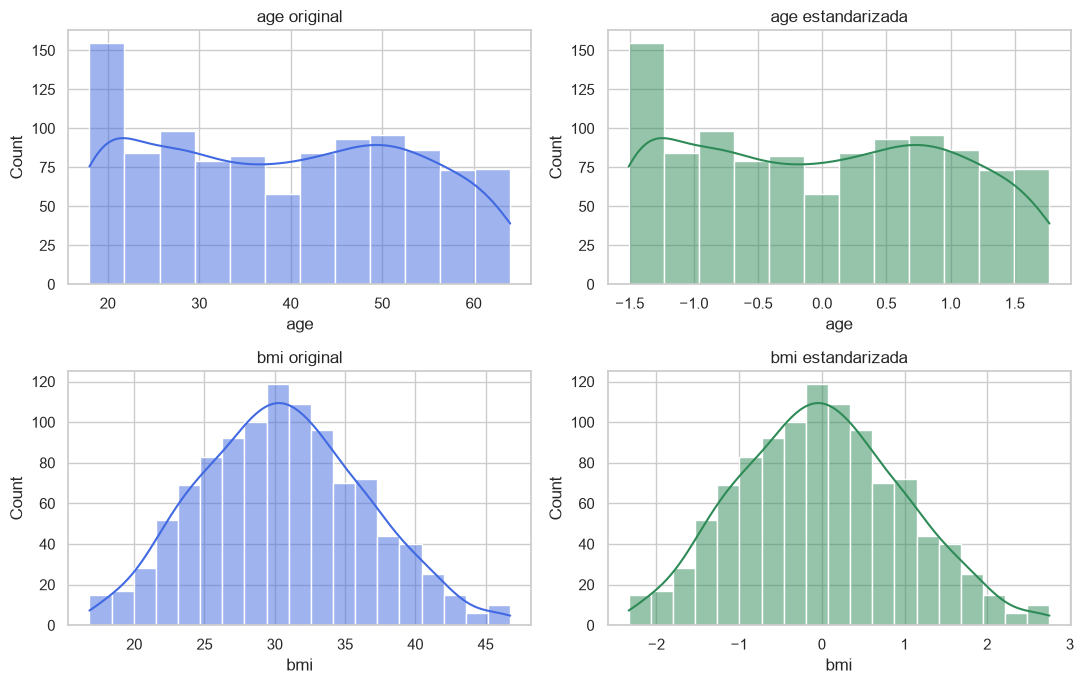

In [16]:
# =====================================================================
# 5.2 ESTANDARIZACIÓN DE LAS VARIABLES CONTINUAS
# =====================================================================
def crear_preprocesador(columnas_continuas: list) -> ColumnTransformer:
    """Crea el transformador que estandariza las variables continuas y deja el resto sin cambios."""
    return ColumnTransformer(
        transformers=[('escalado', StandardScaler(), columnas_continuas)],
        remainder='passthrough',
        verbose_feature_names_out=False,
    ).set_output(transform='pandas')


preprocesador = crear_preprocesador(COLUMNAS_CONTINUAS)

# El ajuste usa solo entrenamiento; prueba se transforma con los parámetros aprendidos
X_train_sc = preprocesador.fit_transform(X_train)
X_test_sc = preprocesador.transform(X_test)

print('[INFO] Variables continuas en entrenamiento tras la estandarización (media ~ 0, desviación ~ 1):')
display(X_train_sc[COLUMNAS_CONTINUAS].agg(['mean', 'std']).T)
print('[INFO] Variables continuas en prueba (se espera una similitud aproximada, no exacta):')
display(X_test_sc[COLUMNAS_CONTINUAS].agg(['mean', 'std']).T)

# Comparación visual antes y después de la estandarización
fig, ejes = plt.subplots(2, 2, figsize=(11, 7))
for columna, fila in zip(['age', 'bmi'], ejes):
    sns.histplot(X_train[columna], kde=True, color='royalblue', ax=fila[0])
    fila[0].set_title(f'{columna} original')
    sns.histplot(X_train_sc[columna], kde=True, color='seagreen', ax=fila[1])
    fila[1].set_title(f'{columna} estandarizada')
plt.tight_layout()
plt.show()

## PASO 6: Selección de atributos — 10 %

La selección combina criterios complementarios, todos calculados únicamente con el conjunto de entrenamiento:

1. **Correlación de Pearson** con charges: mide la asociación lineal individual.
2. **Prueba F (f_regression)**: contrasta si la relación lineal de cada variable con charges es estadísticamente significativa (p-valor).
3. **Información mutua**: captura dependencias no necesariamente lineales.
4. **Factor de inflación de la varianza (VIF)**: detecta multicolinealidad entre variables explicativas; valores superiores a 10 indican redundancia severa.
5. **RFECV** (eliminación recursiva de atributos con validación cruzada): determina el subconjunto que minimiza el error de un modelo lineal.

Criterio de decisión: se conserva una variable cuando su p-valor de la prueba F es menor que 0.05 y, además, es retenida por RFECV. El VIF se utiliza como control de multicolinealidad sobre las variables seleccionadas.

,correlacion,estadistico_F,p_valor,info_mutua,VIF
fumador_obeso,0.8216,"2,201.9940",0.0000,0.3238,2.4662
smoker_yes,0.7976,"1,853.4859",0.0000,0.3698,2.1929
age,0.3157,117.3099,0.0000,1.4184,1.0195
bmi_obeso,0.2078,47.8238,0.0000,0.0850,3.0703
bmi,0.1967,42.6691,0.0000,0.0943,3.0125
children,0.0965,9.9615,0.0016,0.1450,1.0083
region_southeast,0.0734,5.7422,0.0167,0.0207,1.6665
sex_male,0.0629,4.2141,0.0403,0.1454,1.0117
region_southwest,-0.0524,2.9163,0.0880,0.0000,1.5404
region_northwest,-0.0139,0.2051,0.6507,0.0438,1.5402


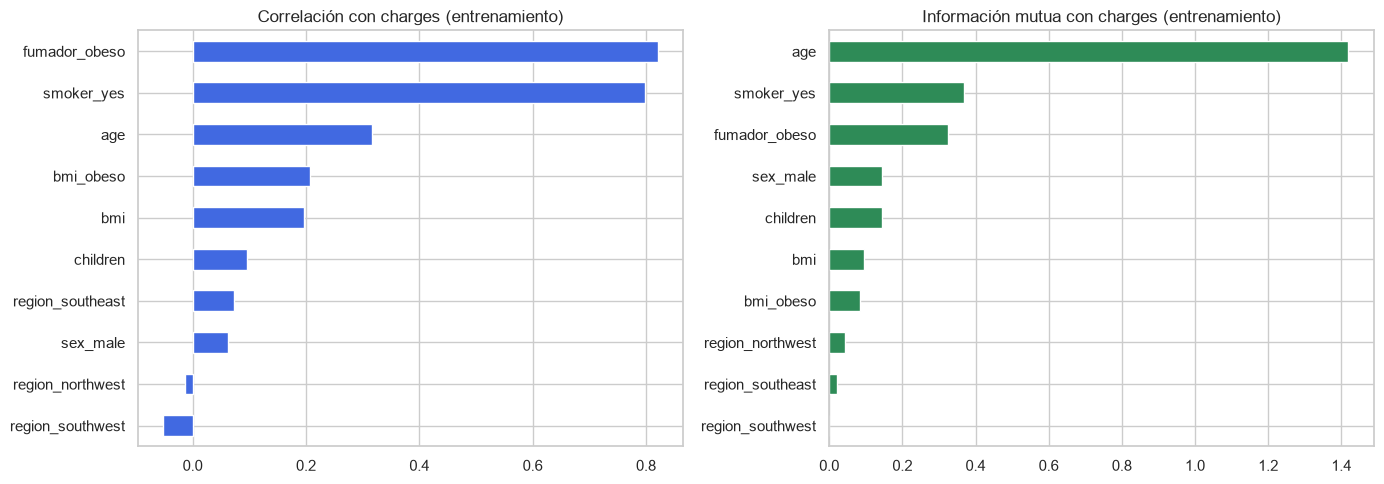

In [17]:
# =====================================================================
# 6.1 MÉTRICAS DE RELEVANCIA Y REDUNDANCIA
# =====================================================================
def calcular_vif(datos: pd.DataFrame) -> pd.Series:
    """Calcula el VIF de cada columna regresándola contra las demás: VIF = 1 / (1 - R2)."""
    vif = {}
    for columna in datos.columns:
        otras = datos.drop(columns=columna)
        r2 = LinearRegression().fit(otras, datos[columna]).score(otras, datos[columna])
        vif[columna] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(vif)


# Prueba F e información mutua (las variables que no son continuas se tratan como discretas)
estadistico_f, p_valor = f_regression(X_train_sc, y_train)
mascara_discretas = np.array([columna not in COLUMNAS_CONTINUAS for columna in X_train_sc.columns])
informacion_mutua = mutual_info_regression(
    X_train_sc, y_train, discrete_features=mascara_discretas, random_state=SEMILLA
)

tabla_seleccion = pd.DataFrame({
    'correlacion': X_train_sc.corrwith(y_train),
    'estadistico_F': estadistico_f,
    'p_valor': p_valor,
    'info_mutua': informacion_mutua,
    'VIF': calcular_vif(X_train_sc),
}, index=X_train_sc.columns)

display(tabla_seleccion.sort_values('correlacion', key=np.abs, ascending=False))

# Visualización de la correlación y de la información mutua
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
tabla_seleccion['correlacion'].sort_values().plot.barh(color='royalblue', ax=ejes[0])
ejes[0].set_title('Correlación con charges (entrenamiento)')
tabla_seleccion['info_mutua'].sort_values().plot.barh(color='seagreen', ax=ejes[1])
ejes[1].set_title('Información mutua con charges (entrenamiento)')
plt.tight_layout()
plt.show()

[INFO] Cantidad óptima de variables según RFECV: 10


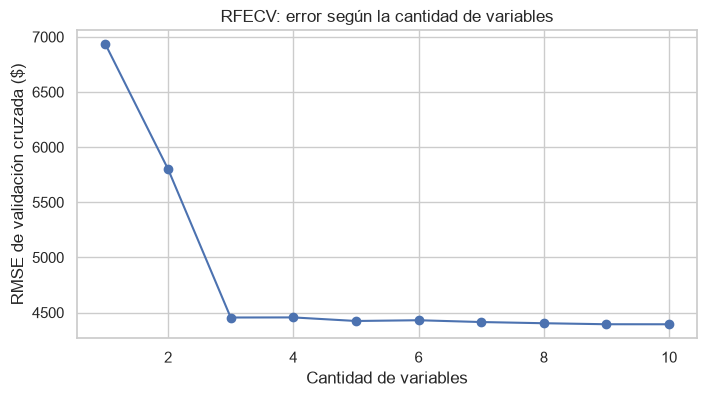

In [18]:
# =====================================================================
# 6.2 ELIMINACIÓN RECURSIVA DE ATRIBUTOS CON VALIDACIÓN CRUZADA (RFECV)
# =====================================================================
selector_rfecv = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEMILLA),
    scoring='neg_root_mean_squared_error',
    min_features_to_select=1,
)
selector_rfecv.fit(X_train_sc, y_train)

tabla_seleccion['RFECV'] = selector_rfecv.support_
print(f'[INFO] Cantidad óptima de variables según RFECV: {selector_rfecv.n_features_}')

# Evolución del error de validación según la cantidad de variables
rmse_cv = -np.asarray(selector_rfecv.cv_results_['mean_test_score'])
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(rmse_cv) + 1), rmse_cv, marker='o')
plt.xlabel('Cantidad de variables')
plt.ylabel('RMSE de validación cruzada ($)')
plt.title('RFECV: error según la cantidad de variables')
plt.show()

In [19]:
# =====================================================================
# 6.3 DECISIÓN FINAL DE VARIABLES
# =====================================================================
ALFA = 0.05
UMBRAL_VIF = 10

tabla_seleccion['seleccionada'] = (tabla_seleccion['p_valor'] < ALFA) & tabla_seleccion['RFECV']
SELECCIONADAS = tabla_seleccion.index[tabla_seleccion['seleccionada']].tolist()
DESCARTADAS = tabla_seleccion.index[~tabla_seleccion['seleccionada']].tolist()

print(f'[INFO] Variables seleccionadas ({len(SELECCIONADAS)}): {SELECCIONADAS}')
print(f'[INFO] Variables descartadas ({len(DESCARTADAS)}): {DESCARTADAS}')

# Control de multicolinealidad sobre las variables seleccionadas
vif_seleccionadas = calcular_vif(X_train_sc[SELECCIONADAS])
vif_altos = vif_seleccionadas[vif_seleccionadas > UMBRAL_VIF]
if vif_altos.empty:
    print(f'[INFO] Ninguna variable seleccionada supera el umbral de VIF = {UMBRAL_VIF}.')
else:
    print(f'[ADVERTENCIA] Variables con VIF superior a {UMBRAL_VIF}:')
    print(vif_altos)

display(tabla_seleccion)

[INFO] Variables seleccionadas (8): ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_southeast', 'bmi_obeso', 'fumador_obeso']
[INFO] Variables descartadas (2): ['region_northwest', 'region_southwest']
[INFO] Ninguna variable seleccionada supera el umbral de VIF = 10.


,correlacion,estadistico_F,p_valor,info_mutua,VIF,RFECV,seleccionada
age,0.3157,117.3099,0.0000,1.4184,1.0195,True,True
bmi,0.1967,42.6691,0.0000,0.0943,3.0125,True,True
children,0.0965,9.9615,0.0016,0.1450,1.0083,True,True
sex_male,0.0629,4.2141,0.0403,0.1454,1.0117,True,True
smoker_yes,0.7976,"1,853.4859",0.0000,0.3698,2.1929,True,True
region_northwest,-0.0139,0.2051,0.6507,0.0438,1.5402,True,False
region_southeast,0.0734,5.7422,0.0167,0.0207,1.6665,True,True
region_southwest,-0.0524,2.9163,0.0880,0.0000,1.5404,True,False
bmi_obeso,0.2078,47.8238,0.0000,0.0850,3.0703,True,True
fumador_obeso,0.8216,"2,201.9940",0.0000,0.3238,2.4662,True,True


**Nota sobre la información mutua y la selección.** La información mutua es un estimador sensible al ruido, por lo que valores bajos (por ejemplo, 0.14 en sex_male y children) no deben interpretarse como relevancia real. La edad obtiene el valor más alto (1.4184) porque, dentro de cada grupo de fumador, su relación con charges es casi determinista (se observa la banda recta de los no fumadores en el gráfico de dispersión), aunque su correlación lineal global sea moderada (0.3157). RFECV conservó las 10 variables porque cada una reduce marginalmente el error, por lo que el filtro efectivo fue la prueba F: se descartaron region_northwest (p = 0.6507) y region_southwest (p = 0.0880) por no ser significativas.

## PASO 7: Validación de datos — 10 %

La validación se desarrolla en tres niveles:

1. **Integridad**: los conjuntos no comparten registros, tienen las mismas columnas, no contienen nulos ni valores infinitos.
2. **Representatividad**: la partición conserva la distribución de las variables relevantes, evaluada con estadísticos descriptivos y la prueba de Kolmogorov-Smirnov de dos muestras.
3. **Validación cruzada**: se estima el desempeño esperado mediante K-Fold con 5 particiones sobre el conjunto de entrenamiento. En cada partición el escalador se reajusta dentro de un Pipeline, de modo que no existe fuga de información. Los resultados sirven para comparar configuraciones y elegir la final sin utilizar el conjunto de prueba.

In [20]:
# =====================================================================
# 7.1 INTEGRIDAD DE LA PARTICIÓN
# =====================================================================
assert X_train.index.intersection(X_test.index).empty, 'Existen registros compartidos entre entrenamiento y prueba.'
assert list(X_train.columns) == list(X_test.columns), 'Los conjuntos tienen columnas distintas.'

for nombre, datos in [('X_train', X_train), ('X_test', X_test)]:
    assert datos.notna().all().all(), f'{nombre} contiene valores nulos.'
    assert np.isfinite(datos.to_numpy(dtype=float)).all(), f'{nombre} contiene valores infinitos.'

print('[INFO] Integridad verificada: sin solapamiento, columnas idénticas, sin nulos ni infinitos.')

# =====================================================================
# 7.2 REPRESENTATIVIDAD DE LA PARTICIÓN
# =====================================================================
resumen_particion = pd.DataFrame({
    'registros': [len(X_train), len(X_test)],
    'charges_media': [y_train.mean(), y_test.mean()],
    'charges_desviacion': [y_train.std(), y_test.std()],
    'pct_fumadores': [X_train['smoker_yes'].mean() * 100, X_test['smoker_yes'].mean() * 100],
    'pct_obesos': [X_train['bmi_obeso'].mean() * 100, X_test['bmi_obeso'].mean() * 100],
}, index=['entrenamiento', 'prueba'])
display(resumen_particion)

# Prueba de Kolmogorov-Smirnov: un p-valor mayor a 0.05 no evidencia diferencias de distribución
ks_charges = stats.ks_2samp(y_train, y_test)
print(f'[INFO] KS charges: estadístico = {ks_charges.statistic:.4f}, p-valor = {ks_charges.pvalue:.4f}')
for columna in ['age', 'bmi']:
    ks = stats.ks_2samp(X_train[columna], X_test[columna])
    print(f'[INFO] KS {columna}: estadístico = {ks.statistic:.4f}, p-valor = {ks.pvalue:.4f}')

[INFO] Integridad verificada: sin solapamiento, columnas idénticas, sin nulos ni infinitos.


,registros,charges_media,charges_desviacion,pct_fumadores,pct_obesos
entrenamiento,1062,"13,229.2743","12,157.4894",20.4331,53.0132
prueba,266,"13,188.2037","11,358.4669",20.3008,50.3759


[INFO] KS charges: estadístico = 0.0486, p-valor = 0.6731
[INFO] KS age: estadístico = 0.0373, p-valor = 0.9151
[INFO] KS bmi: estadístico = 0.0538, p-valor = 0.5482


In [21]:
# =====================================================================
# 7.3 VALIDACIÓN CRUZADA DE CONFIGURACIONES CANDIDATAS
# =====================================================================
COLUMNAS_BASE = [
    'age', 'bmi', 'children', 'sex_male', 'smoker_yes',
    'region_northwest', 'region_southeast', 'region_southwest',
]


def construir_modelo(columnas: list, log_objetivo: bool = False):
    """Construye el modelo completo: estandarización de variables continuas y regresión lineal.

    Cuando log_objetivo es verdadero, el modelo se entrena sobre log(1 + charges) y
    devuelve las predicciones en dólares mediante la transformación inversa.
    """
    continuas = [columna for columna in COLUMNAS_CONTINUAS if columna in columnas]
    pipeline = Pipeline([
        ('preprocesamiento', ColumnTransformer(
            transformers=[('escalado', StandardScaler(), continuas)],
            remainder='passthrough',
            verbose_feature_names_out=False,
        )),
        ('regresion', LinearRegression()),
    ])
    if log_objetivo:
        return TransformedTargetRegressor(regressor=pipeline, func=np.log1p, inverse_func=np.expm1)
    return pipeline


candidatos = {
    'A. Base (sin variables derivadas ni selección)': (COLUMNAS_BASE, False),
    'B. Variables seleccionadas': (SELECCIONADAS, False),
    'C. Variables seleccionadas + log(charges)': (SELECCIONADAS, True),
}

validacion_cruzada = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
metricas_cv = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
}

filas_cv = []
for nombre, (columnas, usar_log) in candidatos.items():
    resultado = cross_validate(
        construir_modelo(columnas, usar_log),
        X_train[columnas], y_train,
        cv=validacion_cruzada, scoring=metricas_cv, return_train_score=True,
    )
    filas_cv.append({
        'modelo': nombre,
        'R2_cv': resultado['test_r2'].mean(),
        'R2_desviacion': resultado['test_r2'].std(),
        'RMSE_cv': -resultado['test_rmse'].mean(),
        'MAE_cv': -resultado['test_mae'].mean(),
        'R2_entrenamiento': resultado['train_r2'].mean(),
    })

resultados_cv = pd.DataFrame(filas_cv).set_index('modelo')
display(resultados_cv)

# La configuración final se elige por el menor RMSE de validación cruzada (en dólares)
mejor_candidato = resultados_cv['RMSE_cv'].idxmin()
COLUMNAS_FINALES, USAR_LOG = candidatos[mejor_candidato]
print(f'[INFO] Configuración elegida: {mejor_candidato}')
print(f'[INFO] Variables finales ({len(COLUMNAS_FINALES)}): {COLUMNAS_FINALES}')
print(f'[INFO] Transformación logarítmica del objetivo: {USAR_LOG}')

,R2_cv,R2_desviacion,RMSE_cv,MAE_cv,R2_entrenamiento
modelo,,,,,
A. Base (sin variables derivadas ni selección),0.7543,0.0384,"5,960.7901","4,142.4459",0.7629
B. Variables seleccionadas,0.8663,0.0240,"4,400.4393","2,415.9422",0.8694
C. Variables seleccionadas + log(charges),0.5019,0.1219,"8,514.1111","4,049.2291",0.5176


[INFO] Configuración elegida: B. Variables seleccionadas
[INFO] Variables finales (8): ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_southeast', 'bmi_obeso', 'fumador_obeso']
[INFO] Transformación logarítmica del objetivo: False


**Interpretación de la validación cruzada.** Las variables derivadas y la selección (candidato B) elevan el R² de validación cruzada de 0.7543 a 0.8663 y reducen el RMSE de 5,960.79 a 4,400.44 dólares respecto al modelo base (candidato A). La transformación logarítmica (candidato C) empeora el desempeño en dólares (R² de 0.5019 y RMSE de 8,514.11 dólares) y muestra mayor inestabilidad entre particiones (desviación del R² de 0.1219), porque al devolver las predicciones a dólares con la transformación inversa se amplifican los errores en los gastos altos. Por esta razón se descarta y se elige el candidato B.

## PASO 8: Entrenamiento mediante Regresión Lineal — 10 %

El modelo final se entrena con todo el conjunto de entrenamiento y la configuración elegida en el paso 7. El Pipeline integra la estandarización y la regresión lineal, por lo que el escalador y los coeficientes se aprenden juntos y el mismo objeto puede reutilizarse en la predicción.

Los coeficientes se presentan en dos escalas: estandarizada (comparable entre variables continuas) y en unidades originales (interpretable directamente, por ejemplo, dólares por cada año de edad). Si se eligió la transformación logarítmica, los coeficientes actúan sobre log(1 + charges) y su efecto se interpreta como variación porcentual.

[INFO] Modelo entrenado correctamente.
[INFO] Intercepto (en escala estandarizada): 8,894.1025


,coef_estandarizado,coef_unidad_original
fumador_obeso,"19,346.4781","19,346.4781"
smoker_yes,"13,493.9205","13,493.9205"
age,"3,600.9722",256.6511
children,666.1067,553.7829
bmi_obeso,-559.9823,-559.9823
bmi,533.3375,90.6528
sex_male,-450.0743,-450.0743
region_southeast,-177.8846,-177.8846


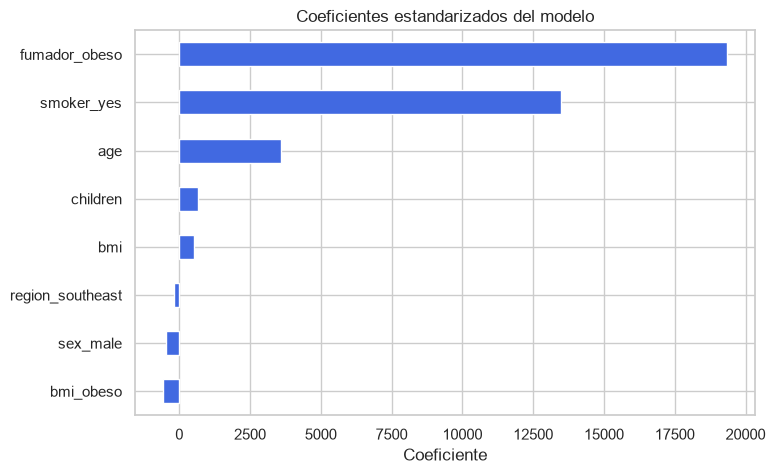

In [22]:
# =====================================================================
# 8.1 ENTRENAMIENTO DEL MODELO FINAL
# =====================================================================
X_train_final = X_train[COLUMNAS_FINALES]
X_test_final = X_test[COLUMNAS_FINALES]

modelo_final = construir_modelo(COLUMNAS_FINALES, USAR_LOG)
modelo_final.fit(X_train_final, y_train)
print('[INFO] Modelo entrenado correctamente.')


def extraer_pipeline(modelo) -> Pipeline:
    """Devuelve el Pipeline entrenado, con o sin transformación del objetivo."""
    return modelo.regressor_ if isinstance(modelo, TransformedTargetRegressor) else modelo


# =====================================================================
# 8.2 COEFICIENTES DEL MODELO
# =====================================================================
pipeline_entrenado = extraer_pipeline(modelo_final)
preprocesamiento = pipeline_entrenado.named_steps['preprocesamiento']
regresion = pipeline_entrenado.named_steps['regresion']
nombres_variables = preprocesamiento.get_feature_names_out()

# Factor de escala de cada variable para convertir el coeficiente a unidades originales
escala = pd.Series(1.0, index=nombres_variables)
continuas_finales = [columna for columna in COLUMNAS_CONTINUAS if columna in COLUMNAS_FINALES]
if continuas_finales:
    escala.loc[continuas_finales] = preprocesamiento.named_transformers_['escalado'].scale_

coeficientes = pd.DataFrame({
    'coef_estandarizado': pd.Series(regresion.coef_, index=nombres_variables),
})
coeficientes['coef_unidad_original'] = coeficientes['coef_estandarizado'] / escala
if USAR_LOG:
    # En escala logarítmica, exp(coef) - 1 aproxima la variación porcentual de charges por unidad
    coeficientes['efecto_pct_unidad_original'] = (np.exp(coeficientes['coef_unidad_original']) - 1) * 100

print(f'[INFO] Intercepto (en escala estandarizada): {regresion.intercept_:,.4f}')
display(coeficientes.sort_values('coef_estandarizado', key=np.abs, ascending=False))

coeficientes['coef_estandarizado'].sort_values().plot.barh(color='royalblue', figsize=(8, 5))
plt.title('Coeficientes estandarizados del modelo')
plt.xlabel('Coeficiente')
plt.show()

## PASO 9: Evaluación — 10 %

La evaluación se realiza sobre el conjunto de prueba, que el modelo no utilizó en ninguna etapa de ajuste. Se reportan:

- **R²** y **R² ajustado**: proporción de la variabilidad de charges explicada por el modelo.
- **MAE**: error absoluto medio, en dólares.
- **RMSE**: raíz del error cuadrático medio, en dólares; penaliza más los errores grandes.

Como referencia mínima se incluye un modelo base que predice siempre la media de entrenamiento. La comparación entre entrenamiento y prueba permite detectar sobreajuste, y el análisis de residuos verifica los supuestos de la regresión lineal.

In [23]:
# =====================================================================
# 9.1 MÉTRICAS DE DESEMPEÑO
# =====================================================================
def calcular_metricas(y_real, y_predicho, n_variables: int) -> dict:
    """Calcula R2, R2 ajustado, MAE y RMSE."""
    n = len(y_real)
    r2 = r2_score(y_real, y_predicho)
    r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - n_variables - 1)
    return {
        'R2': r2,
        'R2_ajustado': r2_ajustado,
        'MAE': mean_absolute_error(y_real, y_predicho),
        'RMSE': np.sqrt(mean_squared_error(y_real, y_predicho)),
    }


prediccion_train = modelo_final.predict(X_train_final)
prediccion_test = modelo_final.predict(X_test_final)

# Modelo de referencia: predice siempre la media del conjunto de entrenamiento
modelo_referencia = DummyRegressor(strategy='mean').fit(X_train_final, y_train)
prediccion_referencia = modelo_referencia.predict(X_test_final)

n_variables = len(COLUMNAS_FINALES)
tabla_metricas = pd.DataFrame({
    'Modelo (entrenamiento)': calcular_metricas(y_train, prediccion_train, n_variables),
    'Modelo (prueba)': calcular_metricas(y_test, prediccion_test, n_variables),
    'Referencia: media (prueba)': calcular_metricas(y_test, prediccion_referencia, 0),
}).T
display(tabla_metricas)

# Interpretación automática de los resultados
r2_train = tabla_metricas.loc['Modelo (entrenamiento)', 'R2']
r2_test = tabla_metricas.loc['Modelo (prueba)', 'R2']
mae_test = tabla_metricas.loc['Modelo (prueba)', 'MAE']
rmse_test = tabla_metricas.loc['Modelo (prueba)', 'RMSE']
print(f'[INFO] El modelo explica {r2_test:.1%} de la variabilidad de charges en el conjunto de prueba.')
print(f'[INFO] El error absoluto medio es de {mae_test:,.2f} dólares y el RMSE de {rmse_test:,.2f} dólares.')
print(f'[INFO] Diferencia de R2 entre entrenamiento y prueba: {r2_train - r2_test:+.4f}')
print(f'[INFO] R2 promedio de validación cruzada para la configuración elegida: '
      f'{resultados_cv.loc[mejor_candidato, "R2_cv"]:.4f}')

,R2,R2_ajustado,MAE,RMSE
Modelo (entrenamiento),0.8693,0.8683,"2,386.9919","4,393.9494"
Modelo (prueba),0.8224,0.8169,"2,561.0371","4,777.4003"
Referencia: media (prueba),-0.0000,-0.0000,"8,574.1139","11,337.1707"


[INFO] El modelo explica 82.2% de la variabilidad de charges en el conjunto de prueba.
[INFO] El error absoluto medio es de 2,561.04 dólares y el RMSE de 4,777.40 dólares.
[INFO] Diferencia de R2 entre entrenamiento y prueba: +0.0468
[INFO] R2 promedio de validación cruzada para la configuración elegida: 0.8663


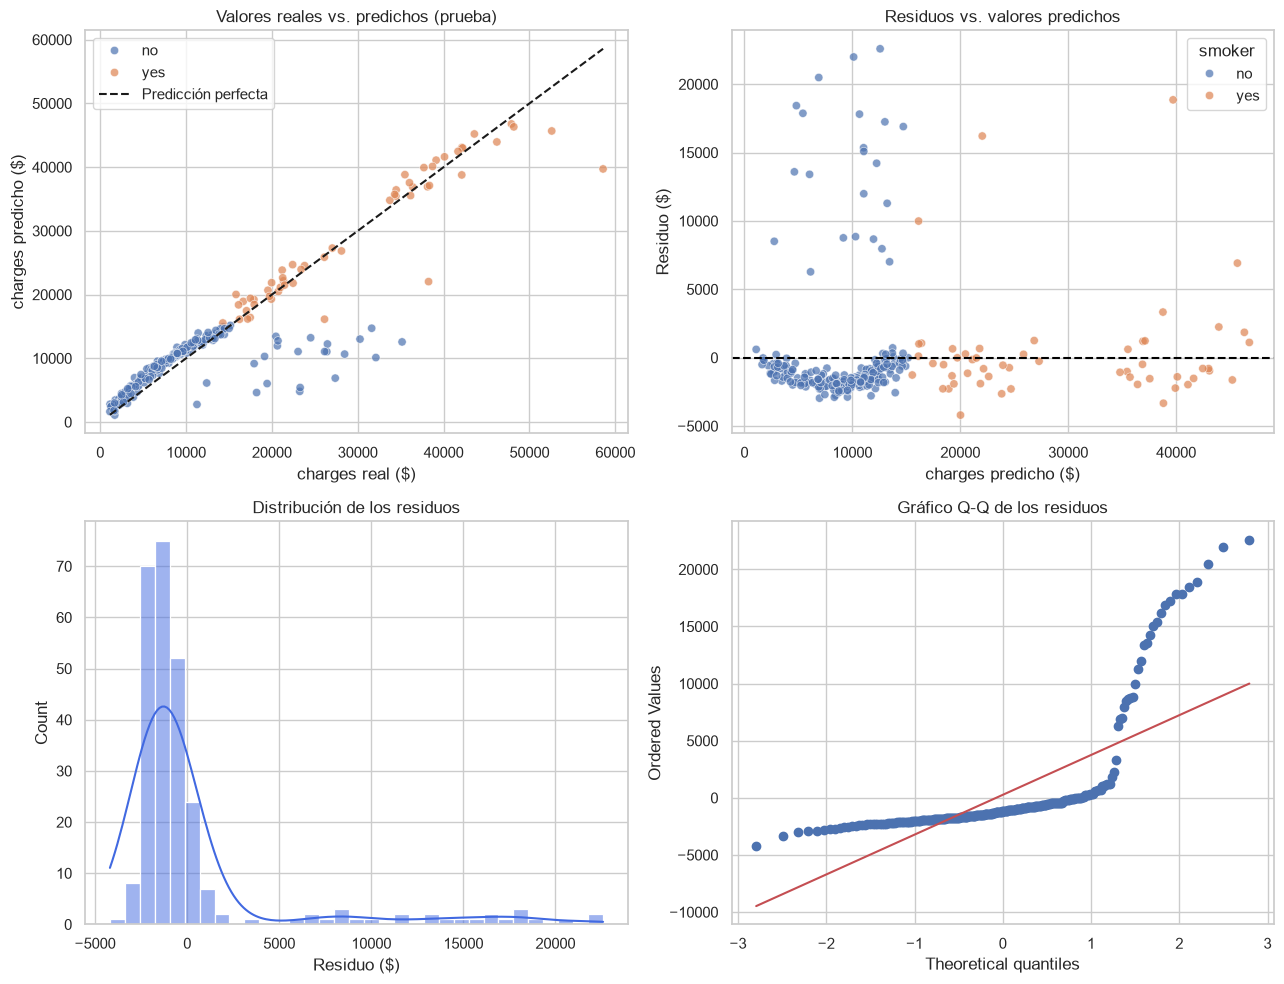

[INFO] Error absoluto en prueba según condición de fumador:


,count,mean,median
smoker,,,
no,212,"2,661.6446","1,595.9388"
yes,54,"2,166.0596","1,241.0973"


In [24]:
# =====================================================================
# 9.2 DIAGNÓSTICO DE RESIDUOS
# =====================================================================
residuos = y_test - prediccion_test
etiqueta_fumador = X_test['smoker_yes'].map({0: 'no', 1: 'yes'}).rename('smoker')

fig, ejes = plt.subplots(2, 2, figsize=(13, 10))

# Valores reales frente a valores predichos
sns.scatterplot(x=y_test, y=prediccion_test, hue=etiqueta_fumador, alpha=0.7, ax=ejes[0, 0])
limite_min, limite_max = y_test.min(), y_test.max()
ejes[0, 0].plot([limite_min, limite_max], [limite_min, limite_max], 'k--', label='Predicción perfecta')
ejes[0, 0].set_title('Valores reales vs. predichos (prueba)')
ejes[0, 0].set_xlabel('charges real ($)')
ejes[0, 0].set_ylabel('charges predicho ($)')
ejes[0, 0].legend()

# Residuos frente a valores predichos (revisión de linealidad y varianza constante)
sns.scatterplot(x=prediccion_test, y=residuos, hue=etiqueta_fumador, alpha=0.7, ax=ejes[0, 1])
ejes[0, 1].axhline(0, color='black', linestyle='--')
ejes[0, 1].set_title('Residuos vs. valores predichos')
ejes[0, 1].set_xlabel('charges predicho ($)')
ejes[0, 1].set_ylabel('Residuo ($)')

# Distribución de los residuos
sns.histplot(residuos, kde=True, color='royalblue', ax=ejes[1, 0])
ejes[1, 0].set_title('Distribución de los residuos')
ejes[1, 0].set_xlabel('Residuo ($)')

# Gráfico Q-Q para evaluar la normalidad de los residuos
stats.probplot(residuos, dist='norm', plot=ejes[1, 1])
ejes[1, 1].set_title('Gráfico Q-Q de los residuos')

plt.tight_layout()
plt.show()

# Error absoluto por grupo de fumador
error_por_grupo = (
    pd.DataFrame({'smoker': etiqueta_fumador, 'error_absoluto': residuos.abs()})
    .groupby('smoker')['error_absoluto']
    .agg(['count', 'mean', 'median'])
)
print('[INFO] Error absoluto en prueba según condición de fumador:')
display(error_por_grupo)

**Interpretación de los resultados.** El modelo explica el 82.2 % de la variabilidad de charges en el conjunto de prueba (R² = 0.8224), con un error absoluto medio de 2,561.04 dólares y un RMSE de 4,777.40 dólares, frente a un RMSE de 11,337.17 dólares del modelo de referencia que predice la media. El R² de entrenamiento (0.8693) y el de validación cruzada (0.8663) son cercanos al de prueba, por lo que no se evidencia sobreajuste severo.

En el gráfico de valores reales frente a predichos, la mayoría de los puntos se alinean con la diagonal. Sin embargo, un grupo de no fumadores con gastos reales de entre 15,000 y 30,000 dólares aproximadamente es subestimado de forma sistemática. Ese grupo origina los residuos positivos de hasta 22,000 dólares y la cola derecha del histograma y del gráfico Q-Q. El resto de los no fumadores presenta residuos ligeramente negativos (sobreestimación de 1,500 a 3,000 dólares aproximadamente). Por ello, los residuos no son normales y la varianza no es constante, lo que indica que las variables disponibles no explican por completo ese grupo de costos elevados. El error absoluto medio es mayor en no fumadores (2,661.64 dólares) que en fumadores (2,166.06 dólares). Este comportamiento es una limitación del enfoque lineal con las variables disponibles y no un error de implementación.

## PASO 10: Predicción con nuevos datos — 5 %

Para llevar el modelo a un uso real se aplican tres buenas prácticas:

1. **Persistencia**: el modelo entrenado, junto con la lista de variables y la versión de scikit-learn, se guarda en un archivo con joblib para reutilizarlo sin reentrenar.
2. **Función de predicción**: recibe observaciones en el formato original del dataset (sin codificar), aplica preparar_variables, valida las entradas y devuelve el costo estimado. Las predicciones negativas, imposibles en el contexto del problema, se limitan a cero.
3. **Prueba de consistencia**: se comprueba que el modelo cargado desde disco, usando el flujo completo desde los datos originales, reproduce exactamente las predicciones del modelo en memoria.

In [25]:
# =====================================================================
# 10.1 PERSISTENCIA DEL MODELO
# =====================================================================
MODELOS_DIR.mkdir(exist_ok=True)
RUTA_MODELO = MODELOS_DIR / 'modelo_regresion_lineal_charges.joblib'

artefacto = {
    'modelo': modelo_final,
    'columnas': COLUMNAS_FINALES,
    'usar_log': USAR_LOG,
    'version_sklearn': sklearn.__version__,
}
joblib.dump(artefacto, RUTA_MODELO)
artefacto_cargado = joblib.load(RUTA_MODELO)
print(f'[INFO] Modelo guardado en {RUTA_MODELO} (scikit-learn {sklearn.__version__}).')


# =====================================================================
# 10.2 FUNCIÓN DE PREDICCIÓN
# =====================================================================
def predecir_gastos(nuevos_datos: pd.DataFrame, artefacto_modelo: dict) -> pd.DataFrame:
    """Estima charges para nuevas observaciones en el formato original del dataset.

    Aplica la misma preparación de variables usada en el entrenamiento, valida las
    entradas y devuelve las observaciones junto con el valor estimado.
    """
    variables = preparar_variables(nuevos_datos)
    estimacion = artefacto_modelo['modelo'].predict(variables[artefacto_modelo['columnas']])

    resultado = nuevos_datos.copy()
    # Los gastos médicos no pueden ser negativos, por lo que se limita el valor inferior
    resultado['charges_estimado'] = np.round(np.clip(estimacion, 0, None), 2)
    return resultado


# =====================================================================
# 10.3 PRUEBA DE CONSISTENCIA DEL FLUJO COMPLETO
# =====================================================================
# Se reproducen las predicciones de prueba partiendo de los datos originales sin codificar
datos_prueba_originales = df_clean.loc[X_test.index].drop(columns=TARGET)
prediccion_flujo_completo = predecir_gastos(datos_prueba_originales, artefacto_cargado)['charges_estimado']

assert np.allclose(prediccion_flujo_completo, np.clip(prediccion_test, 0, None), atol=0.01), \
    'El modelo cargado no reproduce las predicciones originales.'
print('[INFO] Consistencia verificada: el modelo cargado reproduce las predicciones del conjunto de prueba.')

[INFO] Modelo guardado en modelos\modelo_regresion_lineal_charges.joblib (scikit-learn 1.9.0).
[INFO] Consistencia verificada: el modelo cargado reproduce las predicciones del conjunto de prueba.


In [26]:
# =====================================================================
# 10.4 PREDICCIÓN SOBRE NUEVAS OBSERVACIONES
# =====================================================================
nuevos_pacientes = pd.DataFrame([
    {'age': 25, 'sex': 'female', 'bmi': 22.5, 'children': 0, 'smoker': 'no',  'region': 'southwest'},
    {'age': 45, 'sex': 'male',   'bmi': 33.0, 'children': 2, 'smoker': 'yes', 'region': 'southeast'},
    {'age': 60, 'sex': 'female', 'bmi': 28.0, 'children': 1, 'smoker': 'no',  'region': 'northeast'},
    {'age': 35, 'sex': 'male',   'bmi': 27.0, 'children': 3, 'smoker': 'yes', 'region': 'northwest'},
    {'age': 52, 'sex': 'female', 'bmi': 38.5, 'children': 0, 'smoker': 'yes', 'region': 'northeast'},
])

predicciones_nuevas = predecir_gastos(nuevos_pacientes, artefacto_cargado)
print('[INFO] Gastos médicos estimados para nuevas observaciones:')
display(predicciones_nuevas)

# Demostración de la validación de entradas: una categoría inexistente debe ser rechazada
observacion_invalida = nuevos_pacientes.iloc[[0]].assign(smoker='maybe')
try:
    predecir_gastos(observacion_invalida, artefacto_cargado)
except ValueError as error:
    print(f'[INFO] Entrada inválida rechazada correctamente: {error}')

[INFO] Gastos médicos estimados para nuevas observaciones:


,age,sex,bmi,children,smoker,region,charges_estimado
0,25,female,22.5000,0,no,southwest,"3,928.4000"
1,45,male,33.0000,2,yes,southeast,"42,773.3000"
2,60,female,28.0000,1,no,northeast,"13,963.5600"
3,35,male,27.0000,3,yes,northwest,"21,608.0400"
4,52,female,38.5000,0,yes,northeast,"44,588.8400"


[INFO] Entrada inválida rechazada correctamente: Categorías no válidas en smoker: ['maybe']


## CONCLUSIÓN

El desarrollo de la actividad permitió construir un flujo completo y reproducible de Machine Learning, desde la descarga automatizada del dataset hasta la predicción sobre nuevas observaciones, aplicando en cada fase criterios técnicos justificados. Las cifras finales de desempeño se encuentran en las salidas de los pasos 7 y 9.

En términos de resultados, el modelo final (regresión lineal con ocho variables seleccionadas y estandarizadas) alcanzó un R² de 0.8224, un MAE de 2,561.04 dólares y un RMSE de 4,777.40 dólares sobre datos no vistos. En validación cruzada, su R² (0.8663) superó al del modelo base (0.7543) y al de la alternativa con transformación logarítmica (0.5019). Como limitación, el modelo subestima a un grupo de no fumadores con gastos elevados, lo que sugiere la existencia de factores no incluidos en el dataset; para abordarlo se plantean modelos no lineales o basados en árboles.

Los principales aprendizajes alcanzados fueron los siguientes:

- **Calidad y comprensión de los datos**: la revisión de nulos, duplicados, categorías y rangos, junto con el análisis exploratorio, orientó las decisiones posteriores. El EDA identificó la asimetría de la variable objetivo y el papel determinante de la condición de fumador.
- **Tratamiento de outliers con criterio**: no todo valor atípico es un error. Los costos elevados se conservaron por corresponder a casos reales, mientras que los valores extremos de BMI se eliminaron por su efecto de palanca sobre los coeficientes.
- **Ingeniería de variables**: las variables derivadas (indicador de obesidad e interacción con la condición de fumador) permiten que un modelo lineal capture relaciones que de otra forma quedarían sin representar. Su aporte se verificó con validación cruzada frente a un modelo base.
- **Prevención de fuga de datos**: la partición temprana, el ajuste del escalador solo con entrenamiento y el uso de Pipelines garantizan que la evaluación sobre el conjunto de prueba sea una estimación honesta del desempeño en datos nuevos.
- **Validación y selección de modelo**: la validación cruzada permitió comparar configuraciones sin utilizar el conjunto de prueba. El diagnóstico de residuos mostró dónde el modelo es más preciso y dónde existen limitaciones propias del enfoque lineal, como los supuestos de linealidad y varianza constante.
- **Buenas prácticas de ingeniería**: la encapsulación en funciones, la persistencia del modelo, la validación de entradas y la prueba de consistencia acercan el trabajo a un entorno de producción.

Como líneas de mejora futura se plantean el uso de modelos regularizados (Ridge y Lasso), modelos basados en árboles o ensambles para capturar relaciones no lineales, y la comparación de los resultados con un esquema de validación repetida.

Desde el punto de vista formativo, la actividad integró los conocimientos de programación, estadística y bases de datos de la carrera en un caso aplicable al sector salud, y evidenció la importancia de un proceso metodológico ordenado por encima de la sola elección del algoritmo.

## BIBLIOGRAFÍA

Choi, M. (2018). *Medical Cost Personal Datasets* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/mirichoi0218/insurance
